In [38]:
from sklearn.feature_extraction.text import CountVectorizer
import glob
import pandas as pd
import nltk
from nltk import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag

In [39]:
# modeli za ustrezno obdelavo stavkov, besed, ločil....
nltk.download('punkt')     # stavki, besede
nltk.download('wordnet') #lemmatizacija
nltk.download('averaged_perceptron_tagger') #POS tagganje
nltk.download('omw-1.4') 
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_percep

True

In [40]:
# tokenization and lemmatization 
lemmatizer= WordNetLemmatizer()

In [41]:
# pokupčkamo besede s podobnim korenom, pomenom skupaj
# run, runs, running -> run
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('RB'):
        return wordnet.ADV
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    else:
        return wordnet.NOUN

In [42]:
def tokenize_lematize(tekst):
    tokens = word_tokenize(tekst.lower())  # vse besede pišemo z malo začetnico
    tagged = pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if word.isalpha()    # znebimo se ločil, st,...
    ]

In [43]:
base_vectorizer = CountVectorizer(stop_words='english')
base_stopwords = base_vectorizer.get_stop_words()

custom_words = {
    'book', 'novel', 'story', 'reader',
    'edition', 'classic', 'introduction',
    'publish', 'note', 'cover', 'series',
    'time', 'year', 'new', 'make', 'tell',
    'begin', 'just', 'work', 'face',
    'place', 'mean', 'text', 'author', 'original', 'u', 'seller',
    'masterpiece', 'literature', 'best', 'read', 'man', 'men', 'woman', 'life',
    'fiction', 'tale'
}

all_stopwords = list(base_stopwords.union(custom_words))

In [44]:
# CountVectorizer odstrani 'stopwords' in ustvari nenegativno matriko, na (i, j)-tem mestu
# imamo pojavitev besede i v j-tem dokumentu (glej zapiske na tablici)


# vzamemo 49/50 knjig, eno bomo potem poskusali uvrstiti med žanre
filepaths = glob.glob(r'C:\Users\mokro\Desktop\diploma\dipl_data\knjige_opisi\*.txt')
# min_df=2, max_df=0.9 odstranita redke in pogoste besede, to uniči celoten rezultat
vectorizer= CountVectorizer(stop_words=all_stopwords, 
                            tokenizer= tokenize_lematize,
                            input = 'filename', 
                            encoding='latin-1', 
                            min_df=2, 
                            max_df=10)

In [45]:
X = vectorizer.fit_transform(filepaths) 


c:\Users\mokro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\mokro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['far'] not in stop_words.
  warnings.warn(


In [46]:
print(X)

# malo lepše, prikaz
dense_matrix = X.toarray()
print(dense_matrix)

#še lepše
feature_names = vectorizer.get_feature_names_out()
df = pd.DataFrame(dense_matrix, columns=feature_names)
print(df.head())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1338 stored elements and shape (49, 466)>
  Coords	Values
  (0, 328)	1
  (0, 444)	2
  (0, 154)	2
  (0, 40)	2
  (0, 447)	1
  (0, 407)	1
  (0, 297)	1
  (0, 459)	1
  (0, 120)	1
  (0, 163)	1
  (0, 113)	1
  (0, 274)	1
  (0, 319)	1
  (0, 7)	1
  (0, 349)	1
  (0, 384)	1
  (0, 307)	1
  (0, 209)	1
  (0, 207)	1
  (0, 178)	1
  (0, 335)	1
  (0, 25)	1
  (0, 85)	1
  (0, 104)	1
  (0, 422)	1
  :	:
  (48, 205)	1
  (48, 359)	1
  (48, 374)	1
  (48, 300)	2
  (48, 342)	1
  (48, 246)	1
  (48, 286)	1
  (48, 99)	1
  (48, 208)	1
  (48, 98)	1
  (48, 188)	1
  (48, 367)	1
  (48, 293)	1
  (48, 29)	2
  (48, 196)	1
  (48, 114)	1
  (48, 76)	1
  (48, 437)	1
  (48, 169)	2
  (48, 337)	1
  (48, 109)	1
  (48, 232)	1
  (48, 122)	1
  (48, 27)	1
  (48, 368)	1
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 ...
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
   acclaim  achieve  achievement  act  action  adult  adventure  affair  \
0        0      

In [47]:
from sklearn.decomposition import PCA

In [48]:
pca = PCA(n_components=4)  
X_pca = pca.fit_transform(X)

In [49]:
print(pca.explained_variance_ratio_)
print("Skupaj:", sum(pca.explained_variance_ratio_))

[0.15055063 0.0697025  0.058091   0.04265074]
Skupaj: 0.32099486566376884


In [50]:
feature_names = vectorizer.get_feature_names_out()

for i, comp in enumerate(pca.components_):
    top_words = [feature_names[j] for j in comp.argsort()[-15:]]
    print(f"PC{i+1}: {top_words}")

PC1: ['witchcraft', 'turn', 'friend', 'evil', 'student', 'wizarding', 'school', 'death', 'dark', 'wizard', 'lord', 'potter', 'voldemort', 'hogwarts', 'harry']
PC2: ['lose', 'collins', 'cruel', 'second', 'suzanne', 'death', 'turn', 'rebellion', 'win', 'everdeen', 'district', 'hunger', 'capitol', 'game', 'katniss']
PC3: ['forge', 'darkness', 'crack', 'destroy', 'evil', 'lose', 'katniss', 'hobbit', 'rule', 'baggins', 'bilbo', 'power', 'lord', 'dark', 'ring']
PC4: ['evil', 'brontã', 'aunt', 'secret', 'orphan', 'power', 'childhood', 'choice', 'intense', 'force', 'search', 'learn', 'family', 'friendship', 'jane']


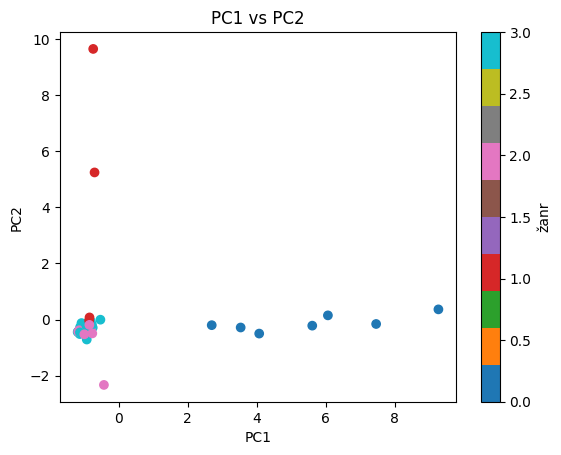

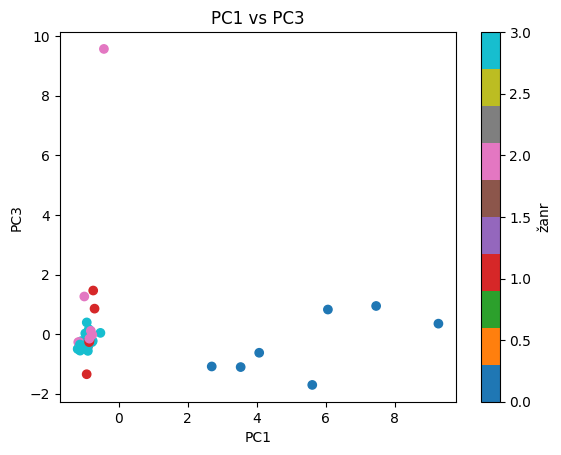

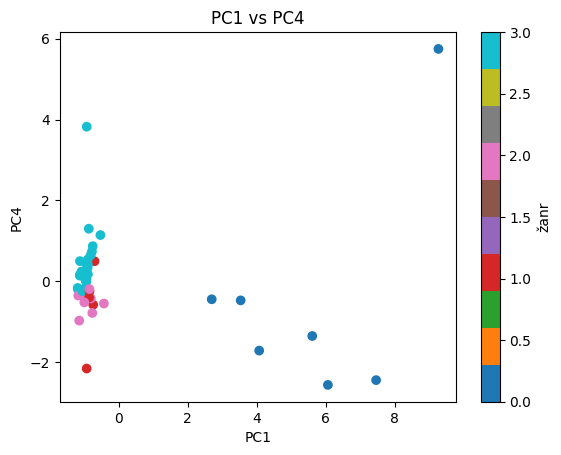

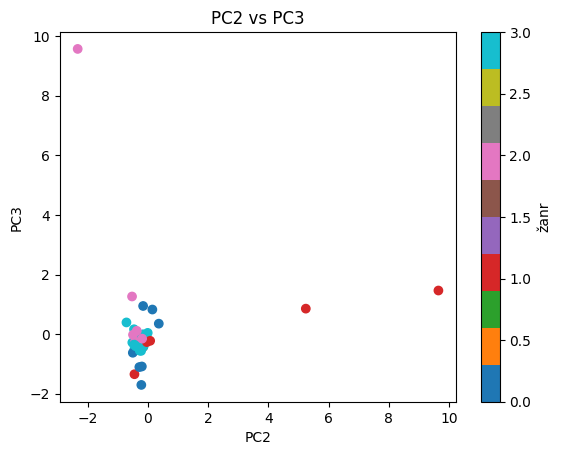

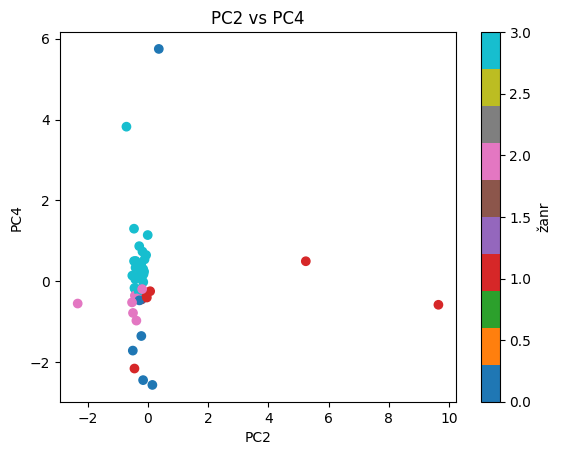

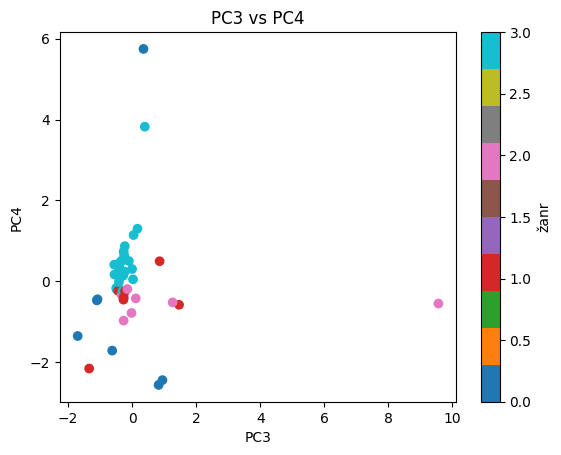

In [51]:
# import matplotlib.pyplot as plt
# labels = X_pca.argmax(axis=1)   

# pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

# for i, j in pairs:
#     plt.figure()
#     plt.scatter(
#         X_pca[:, i],
#         X_pca[:, j],
#         c=labels,       
#         cmap="tab10"    
#     )
#     plt.xlabel(f"PC{i+1}")
#     plt.ylabel(f"PC{j+1}")
#     plt.title(f"PC{i+1} vs PC{j+1}")
#     plt.colorbar(label="žanr")   
#     plt.show()

# plt.show()